# Feature Engineering & Analysis

This notebook performs comprehensive feature engineering on the cleaned Amazon reviews dataset by creating text-based, temporal, metadata, and target features for modeling and analysis.

## 1. Setup & Configuration

In [1]:
import sys, subprocess, importlib.util

REQUIRED = {
    'pandas': 'pandas', 
    'numpy': 'numpy', 
    'sklearn': 'scikit-learn',
    'scipy': 'scipy', 
    'matplotlib': 'matplotlib', 
    'seaborn': 'seaborn',
    'statsmodels': 'statsmodels', 
    'pyarrow': 'pyarrow',
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print(f'Installed: {missing}')

In [2]:
# Import Required Libraries
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

In [3]:
# Configuration
CLEANED_PARQUET = "../data/sourced/clean_reviews.parquet"
FEATURED_PARQUET = "../data/sourced/featured_reviews.parquet"
RANDOM_STATE = 42

print(f"Configuration loaded:")
print(f"  Input file: {CLEANED_PARQUET}")
print(f"  Output file: {FEATURED_PARQUET}\n")

Configuration loaded:
  Input file: ../data/sourced/clean_reviews.parquet
  Output file: ../data/sourced/featured_reviews.parquet



In [4]:
# # Load Cleaned Dataset and sample
# df = pd.read_parquet(CLEANED_PARQUET)

# df = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
# print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]:,} columns\n")

In [5]:
# Load Cleaned Dataset
df = pd.read_parquet(CLEANED_PARQUET)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]:,} columns\n")

Dataset loaded: 8,467,573 rows x 8 columns



## 2. Dataset Overview - BEFORE Feature Engineering

In [6]:
print("Dataset Shape (BEFORE):")
print(f"  {df.shape[0]:,} rows x {df.shape[1]:,} columns\n")

print("Column Names:")
print(f"  {list(df.columns)}\n")

Dataset Shape (BEFORE):
  8,467,573 rows x 8 columns

Column Names:
  ['rating', 'title', 'text', 'images', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase']



In [7]:
print("Data Types (BEFORE):")
print(df.dtypes)

Data Types (BEFORE):
rating                         int8
title                           str
text                            str
images                       object
parent_asin                category
timestamp            datetime64[ms]
helpful_vote                  int32
verified_purchase              bool
dtype: object


In [8]:
print("First 3 rows (BEFORE):")
df.iloc[19:23]

First 3 rows (BEFORE):


,rating,title,text,images,parent_asin,timestamp,helpful_vote,verified_purchase
19,2,Doesn't have NFC as stated!,"Works well enough, microphone and pairing work...","[{'attachment_type': 'IMAGE', 'large_image_url...",B0992TJFM3,2022-04-01 21:32:08.866,6,True
20,5,Used this to add a better subwoofer to my soun...,I have an LG SK9Y and I ran the speaker level ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B07VKFSLKN,2022-02-25 22:35:47.460,6,True
21,4,"Nice card, a bit loud when fans are maxed",Beautiful card. Runs well and seems solid. My ...,[],B088DJQ2PQ,2020-10-25 20:22:58.639,2,True
22,4,A good case for the price,A good case for the price. I was nervous that ...,[],B09FN58JBR,2015-02-09 16:47:55.000,1,True


## 3. Feature Engineering Pipeline

### 3.1 Text Features

In [9]:
# Combine title and text with [SEP] token
df['combined_text'] = (
    df['title'].fillna("").str.strip() + " [SEP] " + 
    df['text'].fillna("").str.strip()
).str.strip()

# Combine title and text without [SEP] token (alternative)
df['review_text'] = (
    df['title'].fillna("").str.strip() + " " + 
    df['text'].fillna("").str.strip()
).str.strip()

# Create review length feature
df['review_length'] = df['review_text'].str.len().fillna(0).astype('int32')

# Create review length feature
df['combined_text_length'] = df['combined_text'].str.len().fillna(0).astype('int32')

# Create title and text length features
df['title_length'] = df['title'].fillna("").str.len().astype('int16')
df['text_length'] = df['text'].fillna("").str.len().astype('int32')

# Create title to text ratio (zero-division safe)
df['title_to_text_ratio'] = (
    df['title_length'] / (df['text_length'] + 1)
).fillna(0).astype('float32')

# Count punctuation marks
df['exclamation_mark'] = df['combined_text'].str.count(r'!').fillna(0).astype('int16')
df['question_mark'] = df['combined_text'].str.count(r'\?').fillna(0).astype('int16')

print("✓ Text features created:")
print("  - combined_text, review_length, title_length, text_length")
print("  - title_to_text_ratio, exclamation_mark, question_mark")
print("  - review_text, combined_text_length (alternative combined feature)")

✓ Text features created:
  - combined_text, review_length, title_length, text_length
  - title_to_text_ratio, exclamation_mark, question_mark
  - review_text, combined_text_length (alternative combined feature)


In [10]:
# Word count
df['word_count'] = df['review_text'].fillna("").astype(str).str.split().str.len().fillna(0).astype('int32')

# Average characters per word (zero-division safe)
df['chars_per_word'] = (df['combined_text_length'] / df['word_count'].clip(lower=1)).round(4)

# Binary feature: is_long_review (1 if >200 words, else 0)
df['is_long'] = (df.get('word_count', 0) > 200).astype(int)

# Create binary feature: title_exists_only
df['title_exists_only'] = (
    (df['title'].notna()) & (df['title'].str.strip().ne('')) &
    ((df['text'].isna()) | (df['text'].str.strip().eq('')))
).astype('int8')

print("✓ Additional text features created:")
print("  - word_count, chars_per_word, is_long, title_exists_only")

✓ Additional text features created:
  - word_count, chars_per_word, is_long, title_exists_only


### 3.2 Image & Media Features

In [11]:
# Create image features
df['image_count'] = df['images'].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
).astype('int16')

df['has_image'] = (df['image_count'] > 0).astype('int8')

df['image_bucket'] = pd.cut(df['image_count'],
                            bins=[-1, 0, 1, 2, 100],
                            labels=['0 images', '1 image', '2 images', '3+ images'])

print("✓ Image features created:")
print("  - image_count, has_image, image_bucket")

✓ Image features created:
  - image_count, has_image, image_bucket


### 3.3 Temporal Features

In [12]:
# Extract temporal features
df['day_of_week'] = df['timestamp'].dt.dayofweek.astype('int8')
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
df['year'] = df['timestamp'].dt.year

# Days since first review
first_review_date = df['timestamp'].min()
df['days_since_first_review'] = (
    (df['timestamp'] - first_review_date).dt.days
).fillna(0).astype('int32')

print("✓ Temporal features created:")
print("  - day_of_week, is_weekend, days_since_first_review")

✓ Temporal features created:
  - day_of_week, is_weekend, days_since_first_review


### 3.4 Purchase & Product Features

In [13]:
# Convert verified_purchase to binary feature
df['is_verified'] = df['verified_purchase'].astype('int8')
if 'verified_purchase' in df.columns:
    df = df.drop(columns=['verified_purchase'])

# Product popularity (review count per parent_asin)
df['product_popularity'] = (
    df.groupby('parent_asin')['parent_asin']
    .transform('count')
    .astype('int32')
)

# Log-transform product popularity to reduce skewness
df['log_popularity'] = np.log1p(df['product_popularity'])

print("✓ Purchase & Product features created:")
print("  - is_verified (from verified_purchase), product_popularity, log_popularity")

✓ Purchase & Product features created:
  - is_verified (from verified_purchase), product_popularity, log_popularity


### 3.5 Rating

In [14]:
# Derive sentiment (categorical)
sentiment_map = {
    1: 'very_negative', 
    2: 'negative', 
    3: 'neutral',
    4: 'positive',       
    5: 'very_positive'
}
df['sentiment'] = df['rating'].map(sentiment_map)

# rating_extremity: distance from neutral → captures U-shaped helpfulness
df['rating_extremity'] = (df['rating'] - 3).abs()

print("✓ Rating features created:")
print("  - sentiment (categorical), rating_extremity (numerical)")

✓ Rating features created:
  - sentiment (categorical), rating_extremity (numerical)


## 4. Dataset Overview - AFTER Feature Engineering

In [15]:
print("Dataset Shape (AFTER):")
print(f"  {df.shape[0]:,} rows x {df.shape[1]:,} columns\n")

print("New Column Names:")
print(f"  {list(df.columns)}\n")

Dataset Shape (AFTER):
  8,467,573 rows x 32 columns

New Column Names:
  ['rating', 'title', 'text', 'images', 'parent_asin', 'timestamp', 'helpful_vote', 'combined_text', 'review_text', 'review_length', 'combined_text_length', 'title_length', 'text_length', 'title_to_text_ratio', 'exclamation_mark', 'question_mark', 'word_count', 'chars_per_word', 'is_long', 'title_exists_only', 'image_count', 'has_image', 'image_bucket', 'day_of_week', 'is_weekend', 'year', 'days_since_first_review', 'is_verified', 'product_popularity', 'log_popularity', 'sentiment', 'rating_extremity']



In [16]:
print("Data Types (AFTER):")
print(df.dtypes)

Data Types (AFTER):
rating                               int8
title                                 str
text                                  str
images                             object
parent_asin                      category
timestamp                  datetime64[ms]
helpful_vote                        int32
combined_text                         str
review_text                           str
review_length                       int32
combined_text_length                int32
title_length                        int16
text_length                         int32
title_to_text_ratio               float32
exclamation_mark                    int16
question_mark                       int16
word_count                          int32
chars_per_word                    float64
is_long                             int64
title_exists_only                    int8
image_count                         int16
has_image                            int8
image_bucket                     category
day_of_week   

In [17]:
print("First 3 rows (AFTER):")
df.iloc[19:23]

First 3 rows (AFTER):


,rating,title,text,images,parent_asin,timestamp,helpful_vote,combined_text,review_text,review_length,...,image_bucket,day_of_week,is_weekend,year,days_since_first_review,is_verified,product_popularity,log_popularity,sentiment,rating_extremity
19,2,Doesn't have NFC as stated!,"Works well enough, microphone and pairing work...","[{'attachment_type': 'IMAGE', 'large_image_url...",B0992TJFM3,2022-04-01 21:32:08.866,6,Doesn't have NFC as stated! [SEP] Works well e...,"Doesn't have NFC as stated! Works well enough,...",659,...,2 images,4,0,2022,9265,1,25,3.258097,negative,1
20,5,Used this to add a better subwoofer to my soun...,I have an LG SK9Y and I ran the speaker level ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B07VKFSLKN,2022-02-25 22:35:47.460,6,Used this to add a better subwoofer to my soun...,Used this to add a better subwoofer to my soun...,654,...,1 image,4,0,2022,9230,1,71,4.276666,very_positive,2
21,4,"Nice card, a bit loud when fans are maxed",Beautiful card. Runs well and seems solid. My ...,[],B088DJQ2PQ,2020-10-25 20:22:58.639,2,"Nice card, a bit loud when fans are maxed [SEP...","Nice card, a bit loud when fans are maxed Beau...",263,...,0 images,6,1,2020,8742,1,8,2.197225,positive,1
22,4,A good case for the price,A good case for the price. I was nervous that ...,[],B09FN58JBR,2015-02-09 16:47:55.000,1,A good case for the price [SEP] A good case fo...,A good case for the price A good case for the ...,315,...,0 images,0,0,2015,6656,1,125,4.836282,positive,1


## 5. Target Variable - Helpful Threshold

### 5.1 Raw Distribution

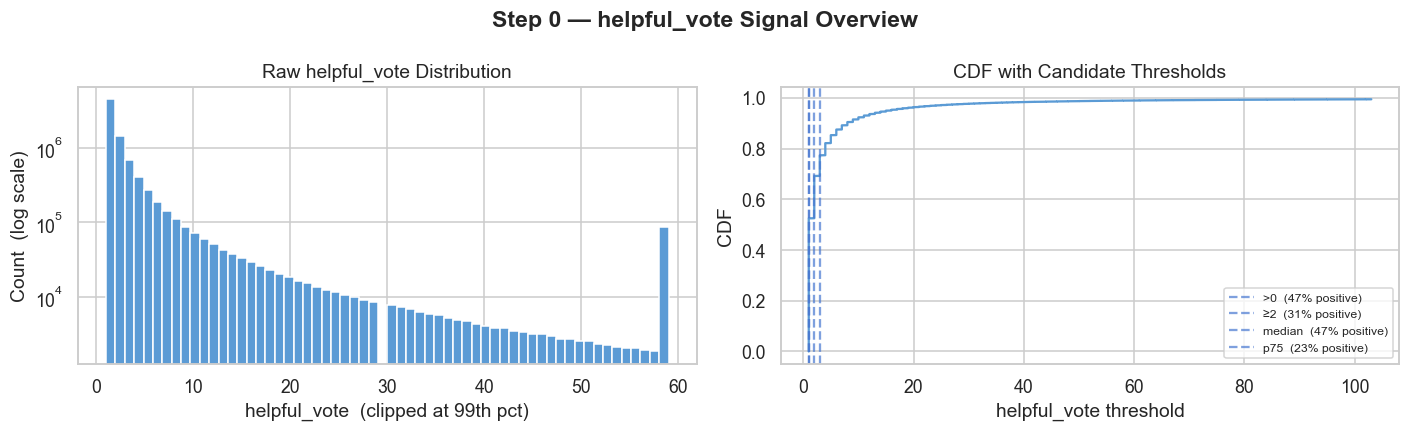

In [18]:
# ── helpful_vote raw distribution ─────────────────────────────────────────
# Why: Before picking a threshold we need to see the shape of the raw signal.
# The distribution is almost certainly heavily right-skewed (Zipf-like), which
# is why a naive > 0 filter leaves the positive class at 100%.

hv = df['helpful_vote'].clip(upper=df['helpful_vote'].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution (log y-scale to show the long tail)
axes[0].hist(hv, bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_xlabel('helpful_vote  (clipped at 99th pct)')
axes[0].set_ylabel('Count  (log scale)')
axes[0].set_title('Raw helpful_vote Distribution')

# Right: CDF — helps us read off threshold positions directly
sorted_hv = np.sort(df['helpful_vote'].values)
cdf = np.arange(1, len(sorted_hv) + 1) / len(sorted_hv)
axes[1].plot(sorted_hv[:int(0.995 * len(sorted_hv))],
             cdf[:int(0.995 * len(sorted_hv))], color='#5b9bd5')
for t, lbl in [(1, '>0'), (2, '≥2'),
               (int(df['helpful_vote'].median()), 'median'),
               (int(df['helpful_vote'].quantile(0.75)), 'p75')]:
    pct = (df['helpful_vote'] > t).mean() if t > 0 else (df['helpful_vote'] >= t).mean()
    axes[1].axvline(t, linestyle='--', alpha=0.7, label=f'{lbl}  ({pct:.0%} positive)')
axes[1].set_xlabel('helpful_vote threshold')
axes[1].set_ylabel('CDF')
axes[1].set_title('CDF with Candidate Thresholds')
axes[1].legend(fontsize=8)

plt.suptitle('Step 0 — helpful_vote Signal Overview', fontweight='bold')
plt.tight_layout(); plt.show()


In [19]:
print(f"Helpful Votes Statistics:")
print(f"  Min: {df['helpful_vote'].min()}")
print(f"  Median: {int(df['helpful_vote'].median())}")
print(f"  Mean: {df['helpful_vote'].mean():.2f}")
print(f"  Max: {df['helpful_vote'].max()}")
print(f"  75th Percentile: {int(df['helpful_vote'].quantile(0.75))}")

Helpful Votes Statistics:
  Min: 1
  Median: 1
  Mean: 5.36
  Max: 46841
  75th Percentile: 3


### 5.2 Threshold Sensitivity Comparision

  Threshold  Positive N  Negative N Positive %        Ratio Imbalance Risk
  > 0  :EDA     8467573           0     100.0% 8467573.00:1           High
> 1: MEDIAN     4019597     4447976      47.5%       0.90:1            Low
   > 3: P75     1914057     6553516      22.6%       0.29:1       Moderate


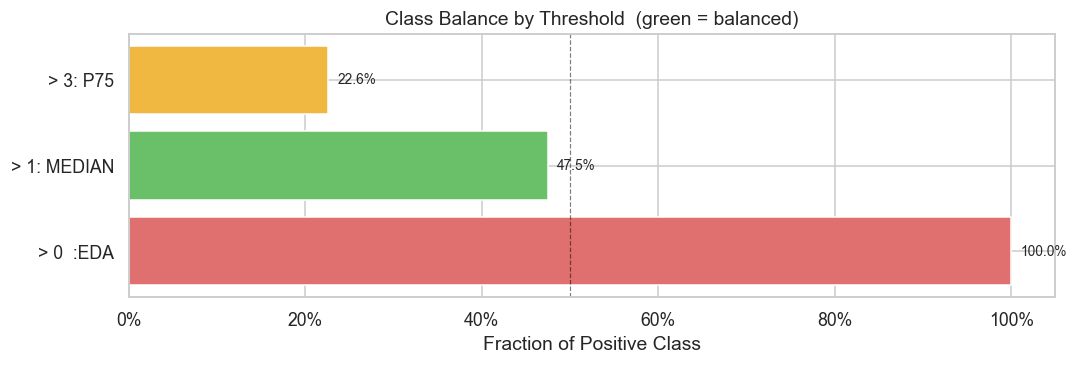

In [20]:
# ── 4. Threshold Sensitivity Comparison ──────────────────────────────────────
# Why: We quantify class balance for every candidate threshold so the choice
# is data-driven, not arbitrary.

median_hv = int(df['helpful_vote'].median())
p75_hv    = int(df['helpful_vote'].quantile(0.75))

thresholds = [
    ('> 0  :EDA',    df['helpful_vote'].gt(0)),
    (f'> {median_hv}: MEDIAN',  df['helpful_vote'].gt(median_hv)),
    (f'> {p75_hv}: P75',  df['helpful_vote'].gt(p75_hv)),
]

rows = []
for name, mask in thresholds:
    pos = mask.sum()
    neg = (~mask).sum()
    pct = pos / len(df)
    rows.append({'Threshold': name, 'Positive N': pos, 'Negative N': neg,
                 'Positive %': f'{pct:.1%}', 'Ratio': f'{pos/max(neg,1):.2f}:1',
                 'Imbalance Risk': 'High' if pct < 0.15 or pct > 0.85 else
                                   'Moderate' if pct < 0.25 or pct > 0.75 else 'Low'})

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

# Visualise class balance
fig, ax = plt.subplots(figsize=(10, 3.5))
names  = [r['Threshold'] for r in rows]
ratios = [float(r['Positive %'].strip('%')) / 100 for r in rows]
bars = ax.barh(names, ratios, color=['#e07070' if r > 0.80 or r < 0.15
                                     else '#f0b840' if r > 0.70 or r < 0.25
                                     else '#6abf69' for r in ratios])
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Fraction of Positive Class')
ax.set_title('Class Balance by Threshold  (green = balanced)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, r in zip(bars, ratios):
    ax.text(r + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{r:.1%}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### 5.3 Create TARGET variable --> is_helpful=0/1

In [21]:
df_save = df.copy()

In [22]:
# Calculate helpful threshold using median
HELPFUL_THRESHOLD = df['helpful_vote'].median()

# Create target variable
df['is_helpful'] = (df['helpful_vote'] > HELPFUL_THRESHOLD).astype('int8')

print(f"Target Variable Distribution:")
print(df['is_helpful'].value_counts().sort_index())
print(f"\nClass Proportions:")
print(df['is_helpful'].value_counts(normalize=True).sort_index())

Target Variable Distribution:
is_helpful
0    4447976
1    4019597
Name: count, dtype: int64

Class Proportions:
is_helpful
0    0.525295
1    0.474705
Name: proportion, dtype: float64


## 6. Helper Functions

In [23]:
def two_class_dist(feature: str, label: str = 'is_helpful', clip_pct: float = 0.99,
                   xlabel: str = None, title: str = None):
    """KDE + rug for a numeric feature split by binary target."""
    sub = df[[feature, label]].dropna()
    q   = sub[feature].quantile(clip_pct)
    sub = sub[sub[feature] <= q]
    fig, ax = plt.subplots(figsize=(9, 4))
    for val, lbl, col in [(0, 'Not Helpful', '#e07070'), (1, 'Helpful', '#5b9bd5')]:
        sns.kdeplot(sub.loc[sub[label] == val, feature], ax=ax,
                    fill=True, alpha=0.35, label=lbl, color=col)
    ax.set_xlabel(xlabel or feature)
    ax.set_title(title or f'Distribution of `{feature}` by Helpfulness')
    ax.legend()
    plt.tight_layout(); plt.show()
    # Point-biserial correlation
    r, p = stats.pointbiserialr(sub[label], sub[feature])
    print(f"  Point-biserial r = {r:+.4f}  (p = {p:.3g})")

def bar_vs_target(feature: str, label: str = 'is_helpful', title: str = None):
    """Stacked bar: proportion helpful per category."""
    sub = df[[feature, label]].dropna()
    order = sorted(sub[feature].unique())
    prop  = sub.groupby(feature)[label].mean()
    counts = sub[feature].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(prop.index.astype(str), prop.values, color='#5b9bd5', edgecolor='white')
    ax.set_ylabel('Proportion Helpful')
    ax.set_xlabel(feature)
    ax.set_title(title or f'Helpfulness Rate by `{feature}`')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    for x, (cat, val) in enumerate(prop.items()):
        ax.text(x, val + 0.005, f'{counts[cat]:,}', ha='center', fontsize=8, color='#555')
    plt.tight_layout(); plt.show()

def compute_mi(features: list, label: str = 'is_helpful', n: int = 100_000) -> pd.Series:
    """Mutual information (classification) for a list of numeric features."""
    sub = df[features + [label]].dropna()
    if len(sub) > n:
        sub = sub.sample(n, random_state=RANDOM_STATE)
    X = sub[features].fillna(0)
    y = sub[label]
    mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    return pd.Series(mi, index=features).sort_values(ascending=False)

def vif_table(features: list) -> pd.DataFrame:
    """Variance Inflation Factor for a list of features."""
    sub = df[features].dropna().sample(min(50_000, len(df)), random_state=RANDOM_STATE)
    X   = sub.fillna(0)
    vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return pd.DataFrame({'Feature': features, 'VIF': vif}).sort_values('VIF', ascending=False)

print("Helpers defined: two_class_dist, bar_vs_target, compute_mi, vif_table")

Helpers defined: two_class_dist, bar_vs_target, compute_mi, vif_table


## 7. Analysis

### Rating

r  → strength + direction of relationship \
p  → statistical significance

rating
1    1726551
2     581945
3     691527
4    1179381
5    4288169
Name: count, dtype: int64

Missing: 0


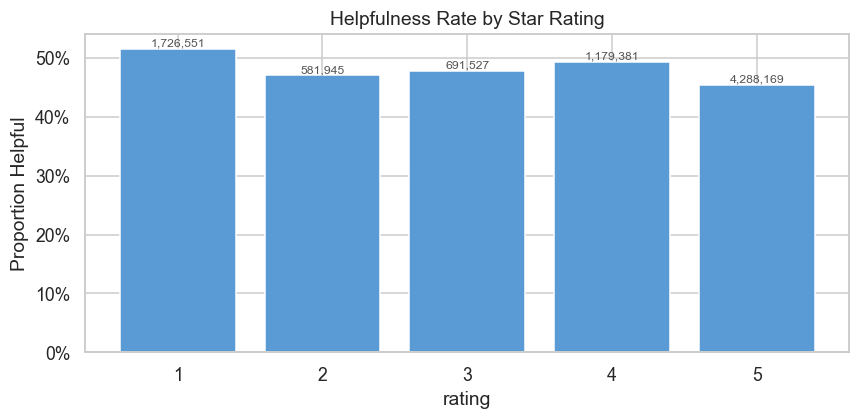

  rating                 point-biserial r = -0.0436  p = 0
  rating_extremity       point-biserial r = -0.0090  p = 7.06e-152


In [24]:
# Why: Star rating is the single strongest proxy for review sentiment.
# Counterintuitively, both 1-star (extremely bad) and 5-star (fanatic praise)
# may generate more votes because they are memorable — "U-shaped" pattern.

print(df['rating'].value_counts().sort_index())
print(f"\nMissing: {df['rating'].isna().sum()}")

bar_vs_target('rating', title='Helpfulness Rate by Star Rating')

# Correlations
for feat in ['rating', 'rating_extremity']:
    if feat in df.columns:
        sub = df[['is_helpful', feat]].dropna()

        r, p = stats.pointbiserialr(
            sub['is_helpful'],
            sub[feat]
        )
        print(f"  {feat:<22} point-biserial r = {r:+.4f}  p = {p:.3g}")

### Verified Purchase 

=== is_verified ===
            Helpfulness Rate    Count
Unverified          0.583453   945112
Verified            0.461042  7522461


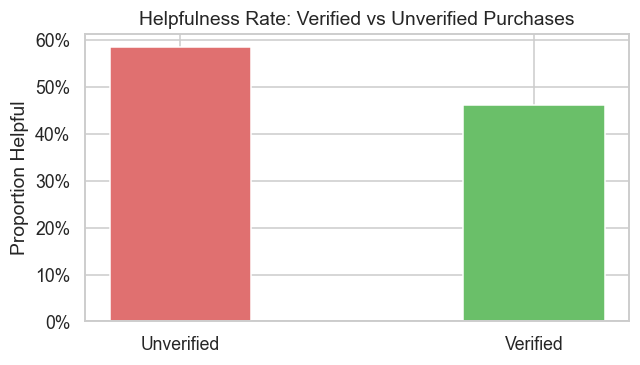


  Welch t-test: t = -225.292  p = 0


In [25]:
# Why: Amazon marks purchases verified when the reviewer actually bought the
# product. Verified buyers typically write more grounded, trustworthy reviews —
# other users are more likely to find them helpful.

if 'is_verified' in df.columns:
    print("=== is_verified ===")
    vc = df.groupby('is_verified')['is_helpful'].agg(['mean', 'count'])
    vc.index = ['Unverified', 'Verified']
    vc.columns = ['Helpfulness Rate', 'Count']
    print(vc.to_string())

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(vc.index, vc['Helpfulness Rate'], color=['#e07070', '#6abf69'],
           edgecolor='white', width=0.4)
    ax.set_ylabel('Proportion Helpful')
    ax.set_title('Helpfulness Rate: Verified vs Unverified Purchases')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.tight_layout(); plt.show()

    t, p_val = stats.ttest_ind(
        df.loc[df['is_verified'] == 1, 'is_helpful'].dropna(),
        df.loc[df['is_verified'] == 0, 'is_helpful'].dropna()
    )
    print(f"\n  Welch t-test: t = {t:.3f}  p = {p_val:.3g}")
else:
    print("is_verified not found — skipping.")

### Image Features

Descriptive stats for image_count:
count    8.467573e+06
mean     1.809044e-01
std      8.188238e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.680000e+02
Name: image_count, dtype: float64


Descriptive stats for has_image:
count    8.467573e+06
mean     8.656565e-02
std      2.811975e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: has_image, dtype: float64

r(image_count, has_image) = 0.7177	 ← high → has_image is redundant


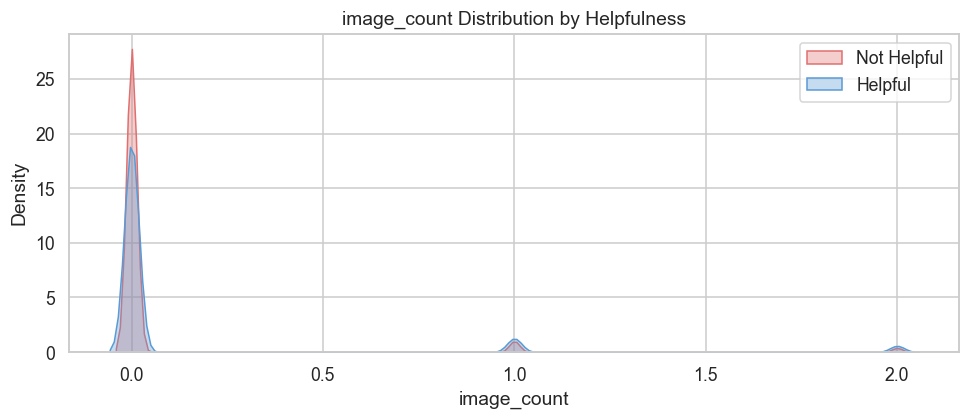

  Point-biserial r = +0.0765  (p = 0)


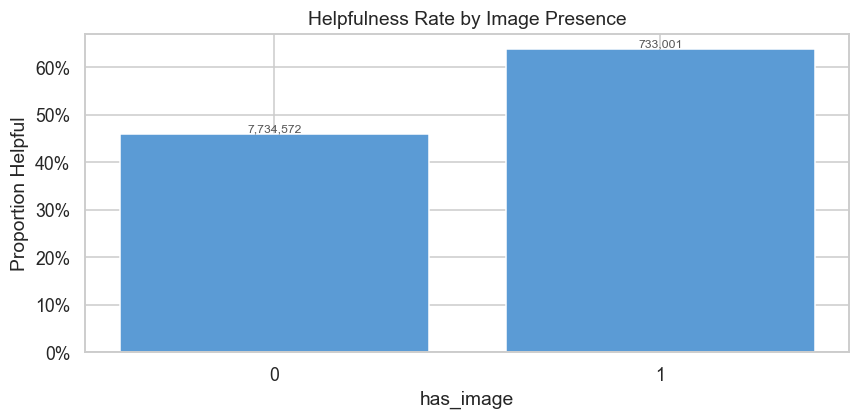

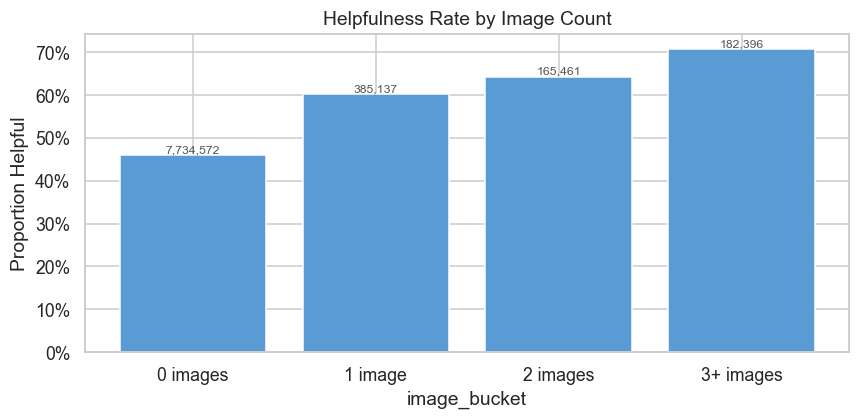

In [26]:
IMAGE_FEATURES = ['image_count', 'has_image']

print("Descriptive stats for image_count:")
print(df['image_count'].describe())

print("\n\nDescriptive stats for has_image:")
print(df['has_image'].describe())

# Correlation between image_count and has_image
r_img = df[['image_count', 'has_image']].corr().iloc[0, 1]
print(f"\nr(image_count, has_image) = {r_img:.4f}\t ← high → has_image is redundant")

# Visualize image_count distribution by helpfulness
two_class_dist('image_count', 
            clip_pct=0.97,
            title='image_count Distribution by Helpfulness')

# Visualize has_image by helpfulness (binary feature)
bar_vs_target('has_image', title='Helpfulness Rate by Image Presence')

# Helpfulness rate: 0, 1, 2, 3+ images
bar_vs_target('image_bucket', title='Helpfulness Rate by Image Count')


### Lexical Features

Descriptive stats for review_length:
count    8467573.0
mean         534.1
std          728.0
min            1.0
25%          159.0
50%          321.0
75%          632.0
max        35296.0
Name: review_length, dtype: float64


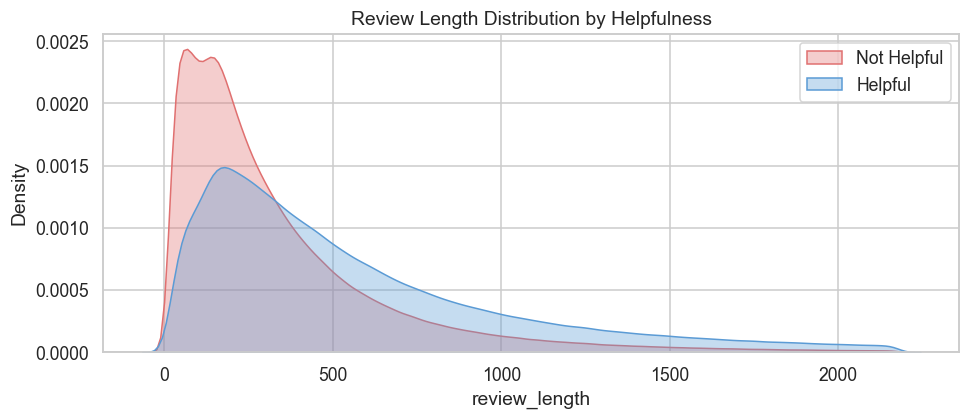

  Point-biserial r = +0.2634  (p = 0)
  Median length — Not Helpful: 238 chars
  Median length — Helpful: 449 chars


In [27]:
print("Descriptive stats for review_length:")
print(df['review_length'].describe().round(1))

two_class_dist('review_length', clip_pct=0.97,
               title='Review Length Distribution by Helpfulness')

# Median length by helpfulness class
for cls, lbl in [(0, 'Not Helpful'), (1, 'Helpful')]:
    med = df.loc[df['is_helpful'] == cls, 'review_length'].median()
    print(f"  Median length — {lbl}: {med:.0f} chars")

  r(word_count, review_length) = 0.9979
  r(chars_per_word, review_length) = -0.1213


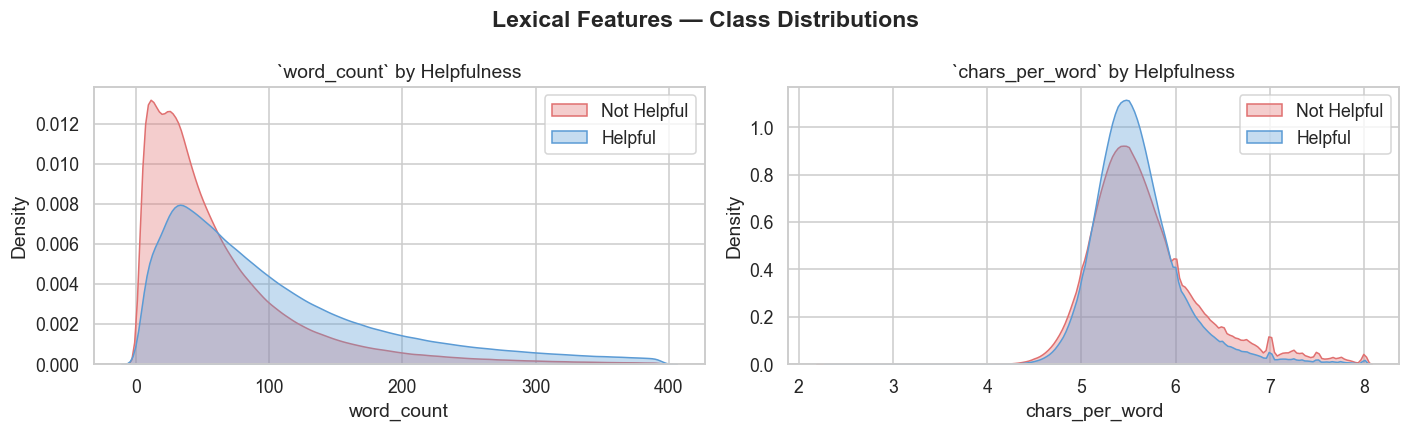

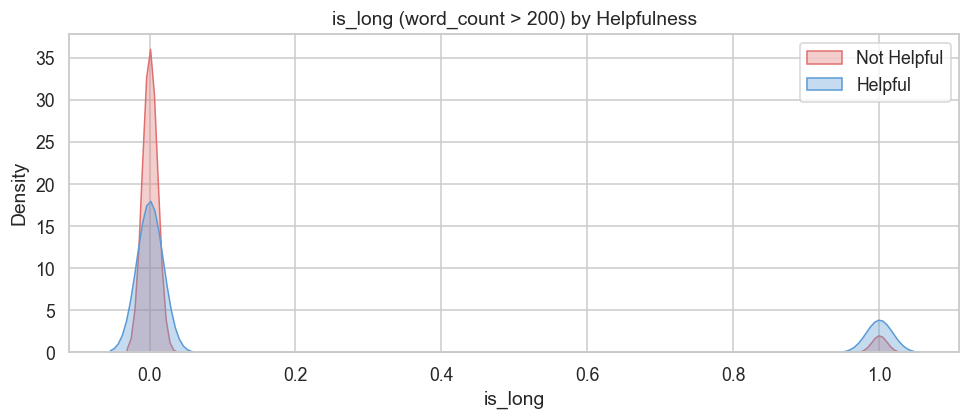

  Point-biserial r = +0.1968  (p = 0)


In [28]:
# Correlation: word_count vs review_length
for f1, f2 in [('word_count', 'review_length'), ('chars_per_word', 'review_length')]:
    if f1 in df.columns and f2 in df.columns:
        r = df[[f1, f2]].corr().iloc[0, 1]
        print(f"  r({f1}, {f2}) = {r:.4f}")

# Distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat, clip in zip(axes, ['word_count', 'chars_per_word'], [0.97, 0.99]):
    if feat not in df.columns:
        continue
    sub = df[[feat, 'is_helpful']].dropna()
    q   = sub[feat].quantile(clip)
    sub = sub[sub[feat] <= q]
    for val, lbl, col in [(0, 'Not Helpful', '#e07070'), (1, 'Helpful', '#5b9bd5')]:
        sns.kdeplot(sub.loc[sub['is_helpful'] == val, feat],
                    ax=ax, fill=True, alpha=0.35, label=lbl, color=col)
    ax.set_title(f'`{feat}` by Helpfulness')
    ax.legend()
plt.suptitle('Lexical Features — Class Distributions', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('is_long', title='is_long (word_count > 200) by Helpfulness')

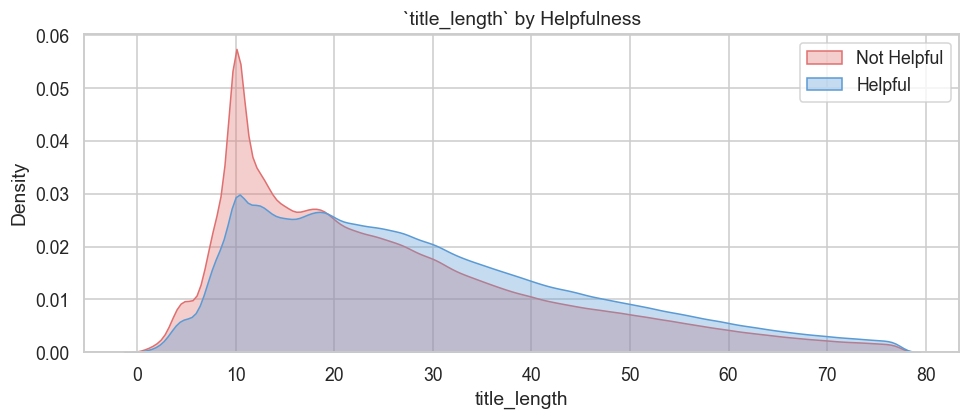

  Point-biserial r = +0.1080  (p = 0)


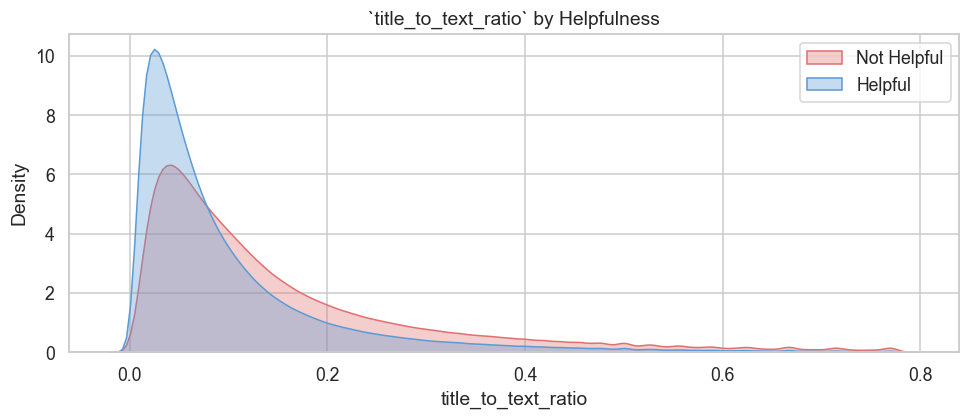

  Point-biserial r = -0.1964  (p = 0)

  r(text_length, review_length) = 0.9997  ← redundant


In [29]:
for feat in ['title_length', 'title_to_text_ratio']:
    two_class_dist(feat, clip_pct=0.97, title=f'`{feat}` by Helpfulness')

# Correlation with review_length
if 'text_length' in df.columns:
    r = df[['text_length', 'review_length']].corr().iloc[0, 1]
    print(f"\n  r(text_length, review_length) = {r:.4f}  "
            f"← {'redundant' if abs(r) > 0.95 else 'non-redundant'}")

Descriptive stats for exclamation marks:
count    8467573.0
mean           0.7
std            1.8
min            0.0
25%            0.0
50%            0.0
75%            1.0
max          497.0
Name: exclamation_mark, dtype: float64


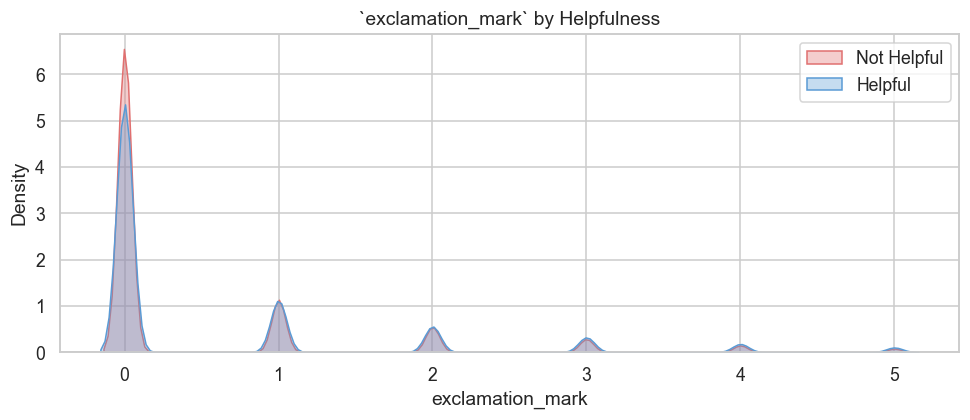

  Point-biserial r = +0.0560  (p = 0)


In [30]:
print("Descriptive stats for exclamation marks:")
print(df['exclamation_mark'].describe().round(1))

two_class_dist('exclamation_mark', clip_pct=0.97, title=f'`exclamation_mark` by Helpfulness')

Descriptive stats for question marks:
count    8467573.0
mean           0.1
std            0.5
min            0.0
25%            0.0
50%            0.0
75%            0.0
max           83.0
Name: question_mark, dtype: float64


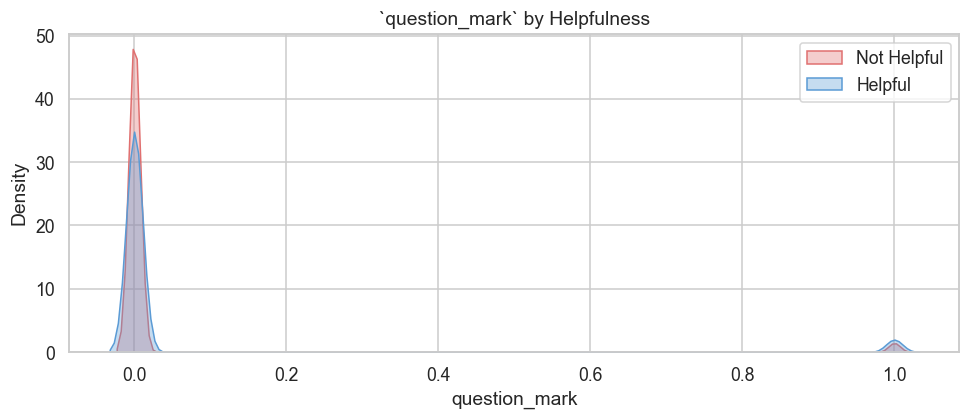

  Point-biserial r = +0.0650  (p = 0)


In [31]:
print("Descriptive stats for question marks:")
print(df['question_mark'].describe().round(1))

two_class_dist('question_mark', clip_pct=0.97, title=f'`question_mark` by Helpfulness')

### Temporal Features

In [32]:
# days_since_first_review: how long has this review been live?
if 'days_since_first_review' not in df.columns:
    ref_date = df['review_date'].max()   # NOTE: use train-set max in production!
    df['days_since_first_review'] = (ref_date - df['review_date']).dt.days
    print(f"Computed days_since_first_review  (ref = {ref_date.date()})")
    print("WARNING: ref_date must be computed from TRAIN set only in production.")

print("\n=== year distribution ===")
print(df['year'].value_counts().sort_index())


=== year distribution ===
year
1996         1
1998         5
1999       288
2000      2562
2001      4565
2002      6119
2003      8602
2004     13757
2005     26216
2006     41911
2007     79810
2008     84382
2009    107159
2010    149941
2011    227293
2012    291509
2013    462145
2014    543335
2015    597739
2016    743134
2017    851904
2018    686772
2019    758437
2020    804183
2021    786464
2022    896076
2023    293264
Name: count, dtype: int64


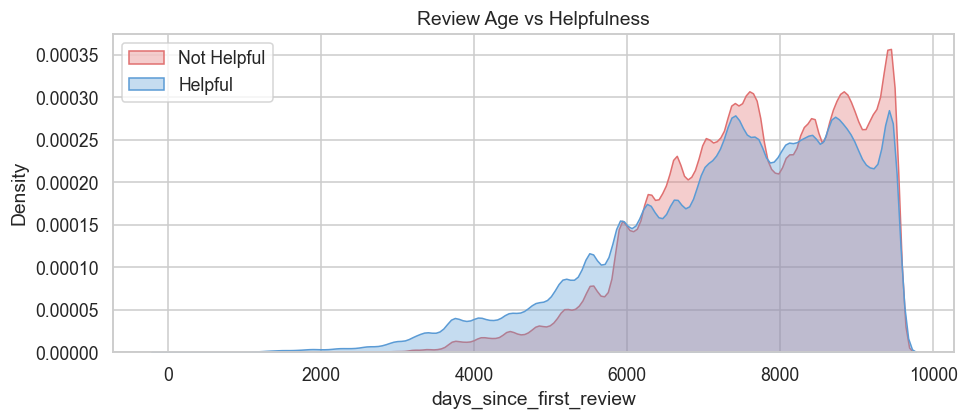

  Point-biserial r = -0.1093  (p = 0)


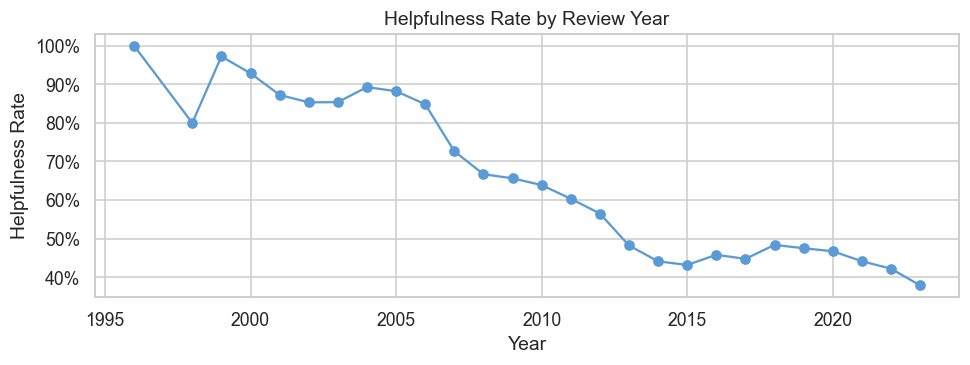

In [33]:
two_class_dist('days_since_first_review', clip_pct=0.97,
                title='Review Age vs Helpfulness')

# Year-level trend
if 'year' in df.columns:
    yr_help = df.groupby('year')['is_helpful'].mean()
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(yr_help.index, yr_help.values, marker='o', color='#5b9bd5')
    ax.set_xlabel('Year')
    ax.set_ylabel('Helpfulness Rate')
    ax.set_title('Helpfulness Rate by Review Year')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.tight_layout(); plt.show()

Descriptive stats for product_popularity:
count    8467573.0
mean         366.8
std         1269.1
min            5.0
25%           23.0
50%           71.0
75%          239.0
max        16910.0
Name: product_popularity, dtype: float64
Descriptive stats for log_popularity:
count    8467573.0
mean           4.4
std            1.6
min            1.8
25%            3.2
50%            4.3
75%            5.5
max            9.7
Name: log_popularity, dtype: float64


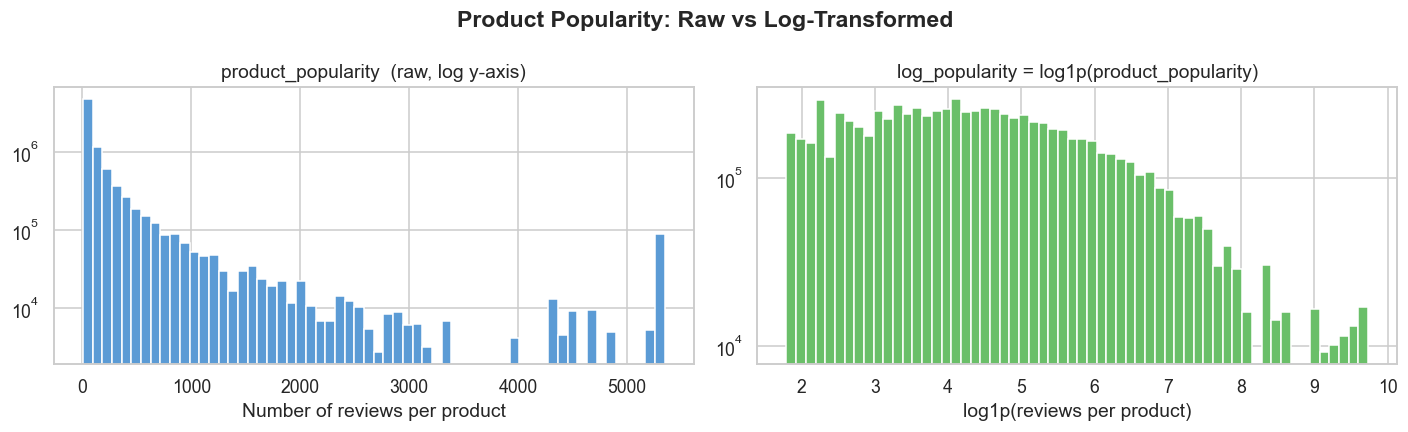

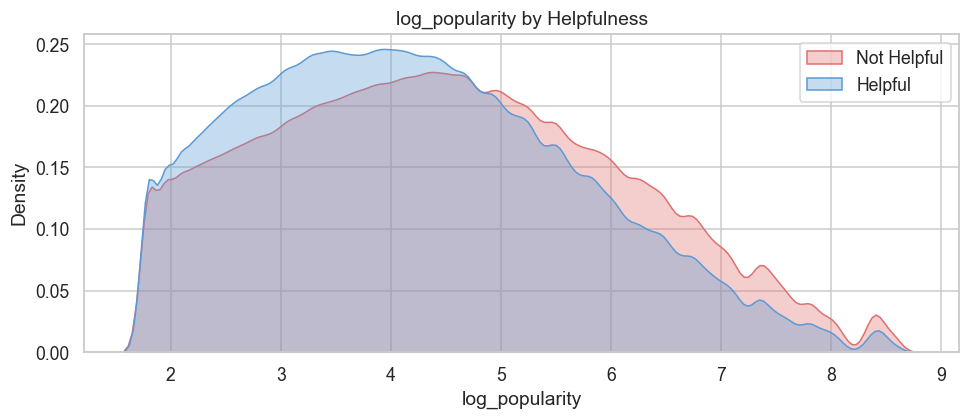

  Point-biserial r = -0.0903  (p = 0)

  Spearman r — product_popularity (raw): -0.0907
  Spearman r — log_popularity:           -0.0907


In [34]:
print("Descriptive stats for product_popularity:")
print(df['product_popularity'].describe().round(1))

print("Descriptive stats for log_popularity:")
print(df['log_popularity'].describe().round(1))


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution — log y to show the power law
axes[0].hist(df['product_popularity'].clip(upper=df['product_popularity'].quantile(0.99)),
                bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_title('product_popularity  (raw, log y-axis)')
axes[0].set_xlabel('Number of reviews per product')

# Log-transformed
axes[1].hist(df['log_popularity'], bins=60, color='#6abf69', edgecolor='white', log=True)
axes[1].set_title('log_popularity = log1p(product_popularity)')
axes[1].set_xlabel('log1p(reviews per product)')

plt.suptitle('Product Popularity: Raw vs Log-Transformed', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('log_popularity', title='log_popularity by Helpfulness')

r_raw = stats.spearmanr(df['product_popularity'].dropna(),
                            df['is_helpful'][:len(df['product_popularity'].dropna())]).correlation
r_log = stats.spearmanr(df['log_popularity'].dropna(),
                            df['is_helpful'][:len(df['log_popularity'].dropna())]).correlation
print(f"\n  Spearman r — product_popularity (raw): {r_raw:+.4f}")
print(f"  Spearman r — log_popularity:           {r_log:+.4f}")

### Text Features

In [35]:
print("Descriptive stats for combined_text:")
print(df['combined_text'].describe())

Descriptive stats for combined_text:
count                    8467573
unique                   8271112
top       Five Stars [SEP] Great
freq                        1504
Name: combined_text, dtype: object



Estimated > 256 tokens (DistilBERT max): 12.5% of reviews → will be truncated


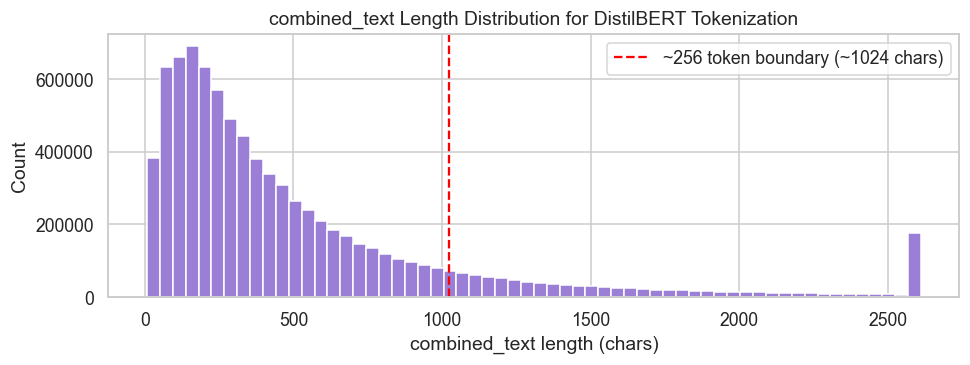


Estimated > 512 tokens (DistilBERT max): 3.4% of reviews → will be truncated


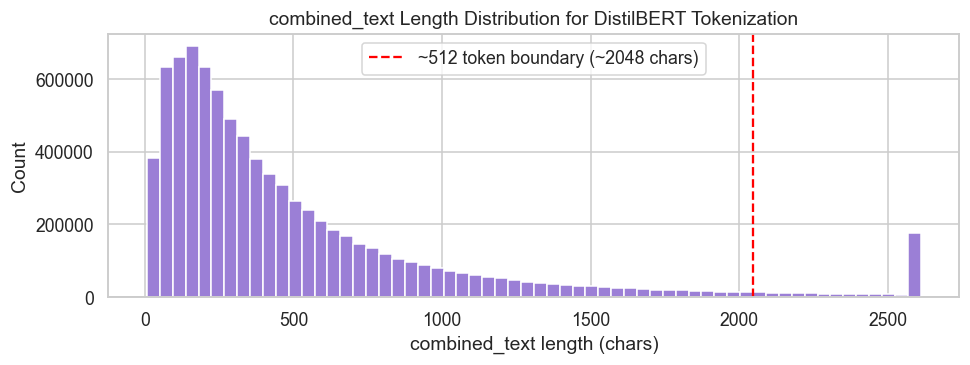

In [36]:
tokens = [256, 512]

for token in tokens:
    # Token length estimate (rough: 1 token ≈ 4 chars)
    est_tokens = (df['combined_text_length'] / 4).round(0).astype(int)
    over_limit = (est_tokens > token).mean()
    print(f"\nEstimated > {token} tokens (DistilBERT max): {over_limit:.1%} of reviews → will be truncated")

    # Length distribution
    fig, ax = plt.subplots(figsize=(9, 3.5))
    clip = df['combined_text_length'].quantile(0.98)
    ax.hist(df['combined_text_length'].clip(upper=clip), bins=60, color='#9b7fd6', edgecolor='white')
    ax.axvline(token * 4, color='red', linestyle='--', label=f'~{token} token boundary (~{token * 4} chars)')
    ax.set_xlabel('combined_text length (chars)')
    ax.set_ylabel('Count')
    ax.set_title('combined_text Length Distribution for DistilBERT Tokenization')
    ax.legend()
    plt.tight_layout(); plt.show()

In [37]:
has_text = (df['text'].notna()) & (df['text'].str.strip().ne(''))
only_title = (~has_text) & (df['title'].notna()) & (df['title'].str.strip().ne(''))

# Create comparison
comparison = pd.DataFrame({
    'Group': ['Title + Text', 'Title Only'],
    'Count': [has_text.sum(), only_title.sum()],
    'Helpful Count': [
        df.loc[has_text, 'is_helpful'].sum(),
        df.loc[only_title, 'is_helpful'].sum()
    ],
    'Helpfulness Rate': [
        df.loc[has_text, 'is_helpful'].mean(),
        df.loc[only_title, 'is_helpful'].mean()
    ]
})

print("="*70)
print("HELPFULNESS COMPARISON: Title+Text vs Title Only")
print("="*70)
print(comparison.to_string(index=False))

HELPFULNESS COMPARISON: Title+Text vs Title Only
       Group   Count  Helpful Count  Helpfulness Rate
Title + Text 8460952        4017161          0.474788
  Title Only    6621           2436          0.367920


Reviews with title but no text:
title_exists_only
0    8460952
1       6621
Name: count, dtype: int64

Proportion: 0.078%

HELPFULNESS ANALYSIS: Title Exists But Text Does Not


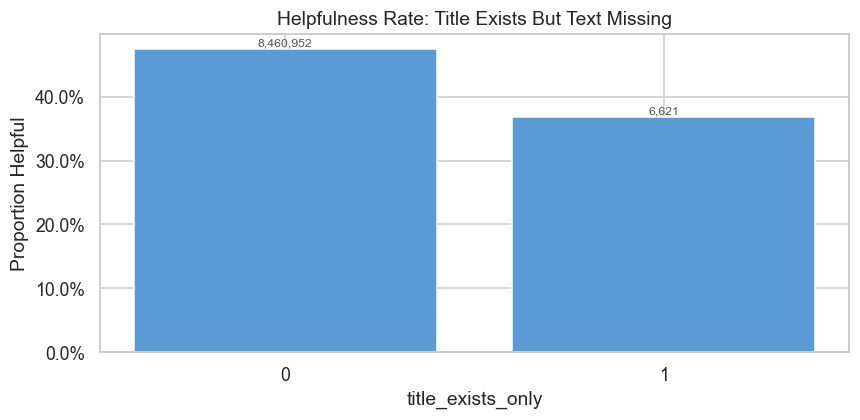


Point-biserial correlation: r = -0.0060  (p = 7.27e-68)

is_helpful         Not Helpful  Helpful    Total
title_exists_only                               
Text Present           4443791  4017161  8460952
Text Missing              4185     2436     6621
Total                  4447976  4019597  8467573


In [38]:
print("Reviews with title but no text:")
print(df['title_exists_only'].value_counts())
print(f"\nProportion: {df['title_exists_only'].mean():.3%}")

# Analyze relationship with is_helpful
print("\n" + "="*60)
print("HELPFULNESS ANALYSIS: Title Exists But Text Does Not")
print("="*60)

bar_vs_target('title_exists_only', 
              title='Helpfulness Rate: Title Exists But Text Missing')

# Correlation
sub = df[['is_helpful', 'title_exists_only']].dropna()
r, p = stats.pointbiserialr(sub['is_helpful'], sub['title_exists_only'])
print(f"\nPoint-biserial correlation: r = {r:+.4f}  (p = {p:.3g})")

# Cross-tabulation
print("\n" + "="*60)
ct = pd.crosstab(df['title_exists_only'], df['is_helpful'], margins=True)
ct = ct.rename(index={0: 'Text Present', 1: 'Text Missing', 'All': 'Total'},
               columns={0: 'Not Helpful', 1: 'Helpful', 'All': 'Total'})
print(ct)

### Overall

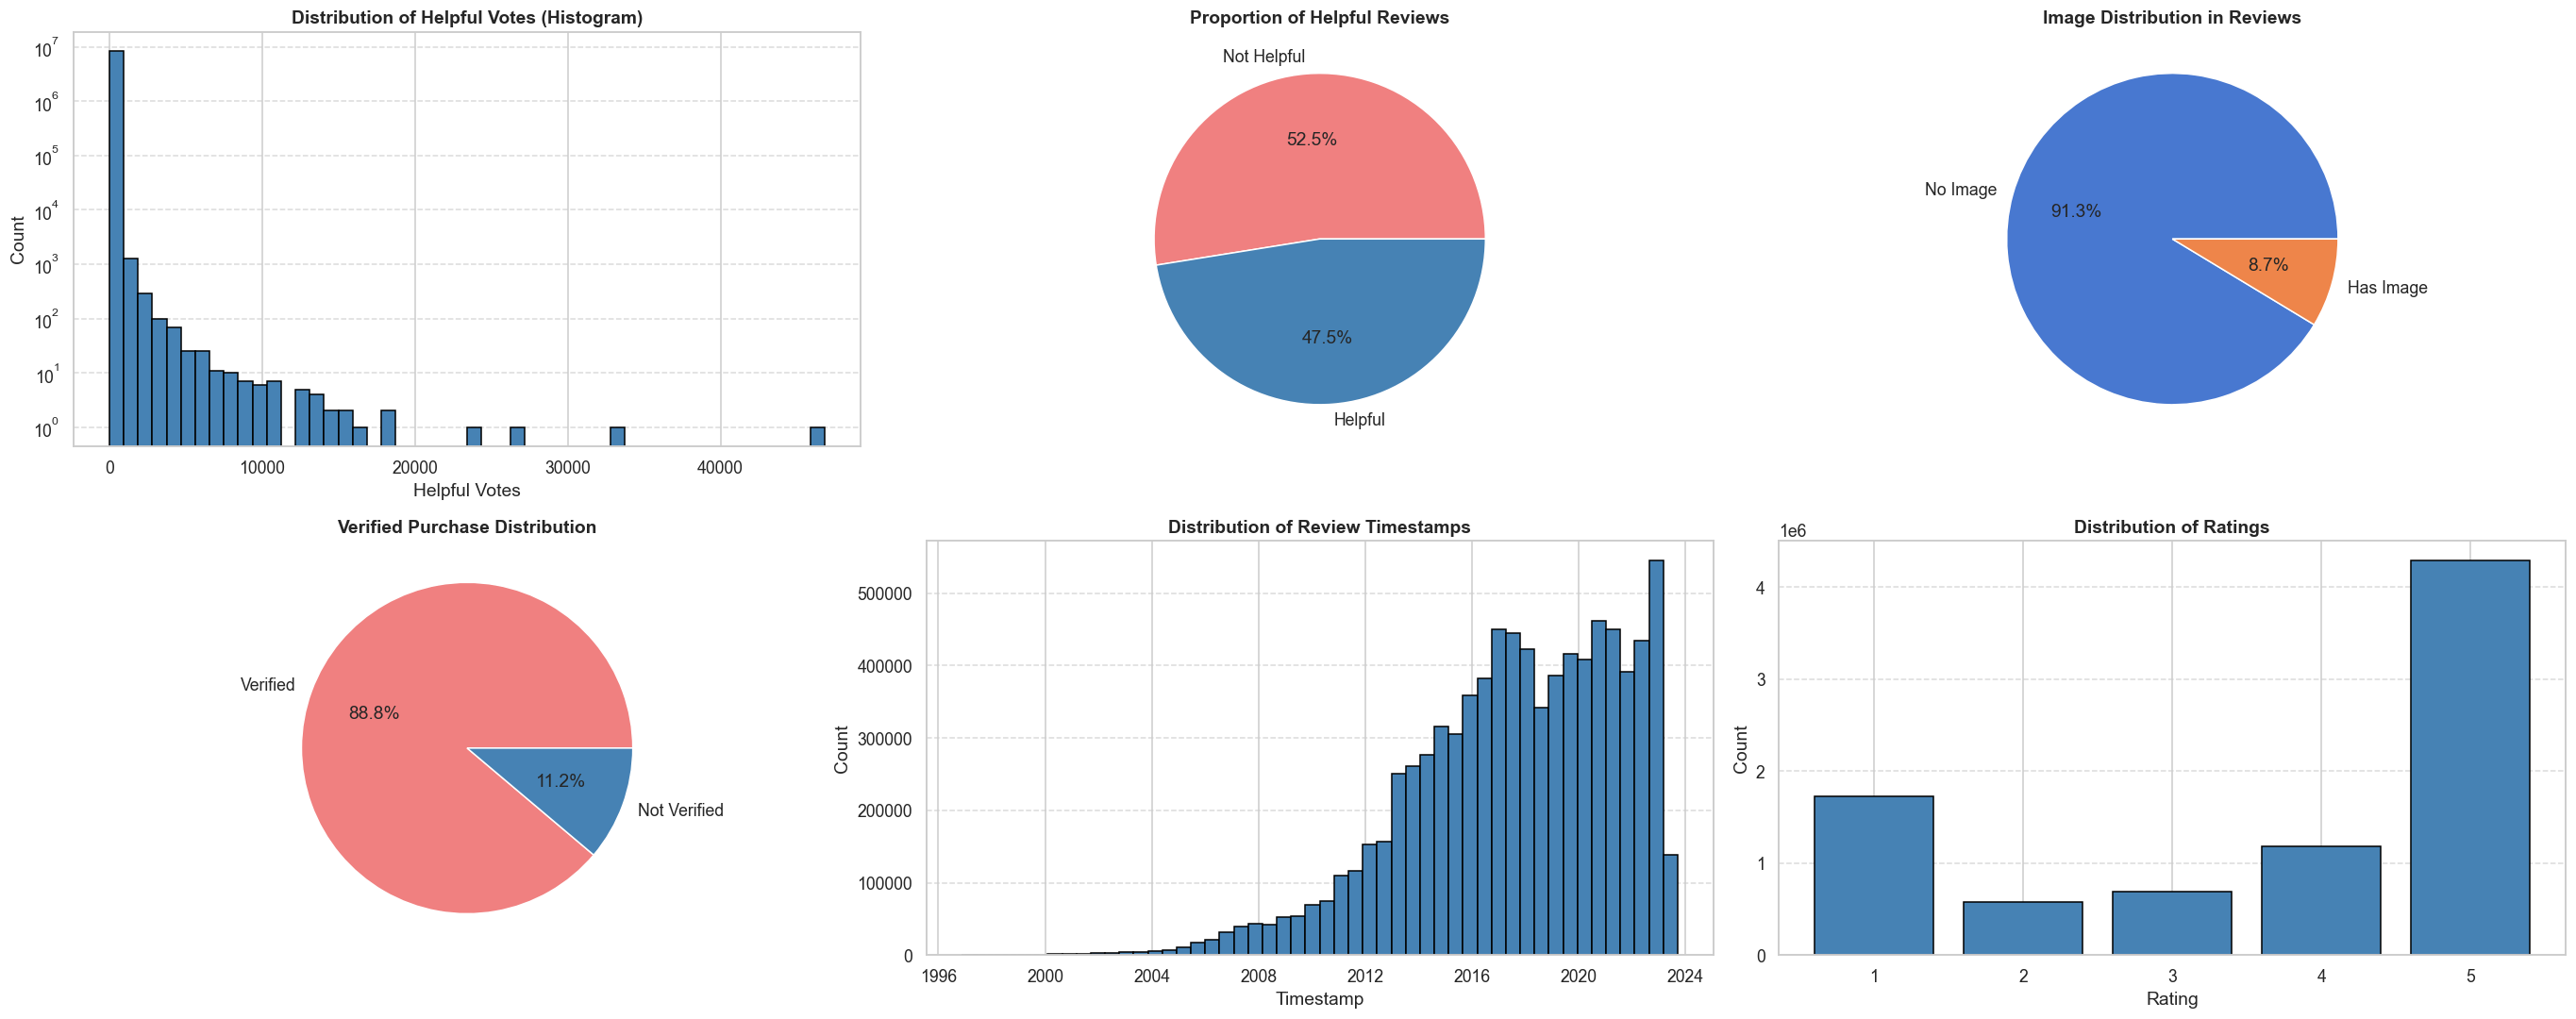


⭐ Rating Distribution:
  1:  20.4% ██████
  2:   6.9% ██
  3:   8.2% ██
  4:  13.9% ████
  5:  50.6% ████████████████


<Figure size 704x528 with 0 Axes>

In [39]:
# Section 4: All Visualizations Combined into Subplots
fig, axes = plt.subplots(2, 3, figsize=(25, 10))
axes = axes.flatten()


# 1. Helpful Votes Histogram
axes[0].hist(df['helpful_vote'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Helpful Votes (Histogram)', fontweight='bold')
axes[0].set_xlabel('Helpful Votes')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Helpful Votes Pie Chart
is_helpful_review = df['is_helpful']
counts = is_helpful_review.value_counts(sort=False).sort_index()
axes[1].pie(counts, labels=['Not Helpful', 'Helpful'], autopct='%1.1f%%', 
            colors=['lightcoral', 'steelblue'])
axes[1].set_title('Proportion of Helpful Reviews', fontweight='bold')

# 3. Image Distribution
has_image = df['has_image'].value_counts()
axes[2].pie(has_image.values, 
            labels=['Has Image' if i else 'No Image' for i in has_image.index],
            autopct='%1.1f%%')
axes[2].set_title('Image Distribution in Reviews', fontweight='bold')

# 4. Verified Purchase Distribution
verified = df['is_verified'].value_counts()
axes[3].pie(verified.values, 
            labels=['Verified' if v else 'Not Verified' for v in verified.index],
            autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
axes[3].set_title('Verified Purchase Distribution', fontweight='bold')

# 5. Timestamp Distribution
axes[4].hist(df['timestamp'], bins=50, color='steelblue', edgecolor='black')
axes[4].set_title('Distribution of Review Timestamps', fontweight='bold')
axes[4].set_xlabel('Timestamp')
axes[4].set_ylabel('Count')
axes[4].grid(axis='y', linestyle='--', alpha=0.7)

# 6. Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[5].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[5].set_title('Distribution of Ratings', fontweight='bold')
axes[5].set_xlabel('Rating')
axes[5].set_ylabel('Count')
axes[5].set_xticks(rating_counts.index)
axes[5].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print statistics after the plot
print(f"\n⭐ Rating Distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {rating}: {pct:5.1f}% {bar}")

plt.tight_layout()
plt.show()

## 8. Statistical Evidence

In [40]:
NUMERIC_COLS = df.select_dtypes(include='number').columns

if 'helpful_vote' in NUMERIC_COLS:
    NUMERIC_COLS = NUMERIC_COLS.drop('helpful_vote')

print(f"Numeric features available for MI and VIF: {NUMERIC_COLS}")

Numeric features available for MI and VIF: Index(['rating', 'review_length', 'combined_text_length', 'title_length',
       'text_length', 'title_to_text_ratio', 'exclamation_mark',
       'question_mark', 'word_count', 'chars_per_word', 'is_long',
       'title_exists_only', 'image_count', 'has_image', 'day_of_week',
       'is_weekend', 'year', 'days_since_first_review', 'is_verified',
       'product_popularity', 'log_popularity', 'rating_extremity',
       'is_helpful'],
      dtype='str')


CORRELATION ANALYSIS


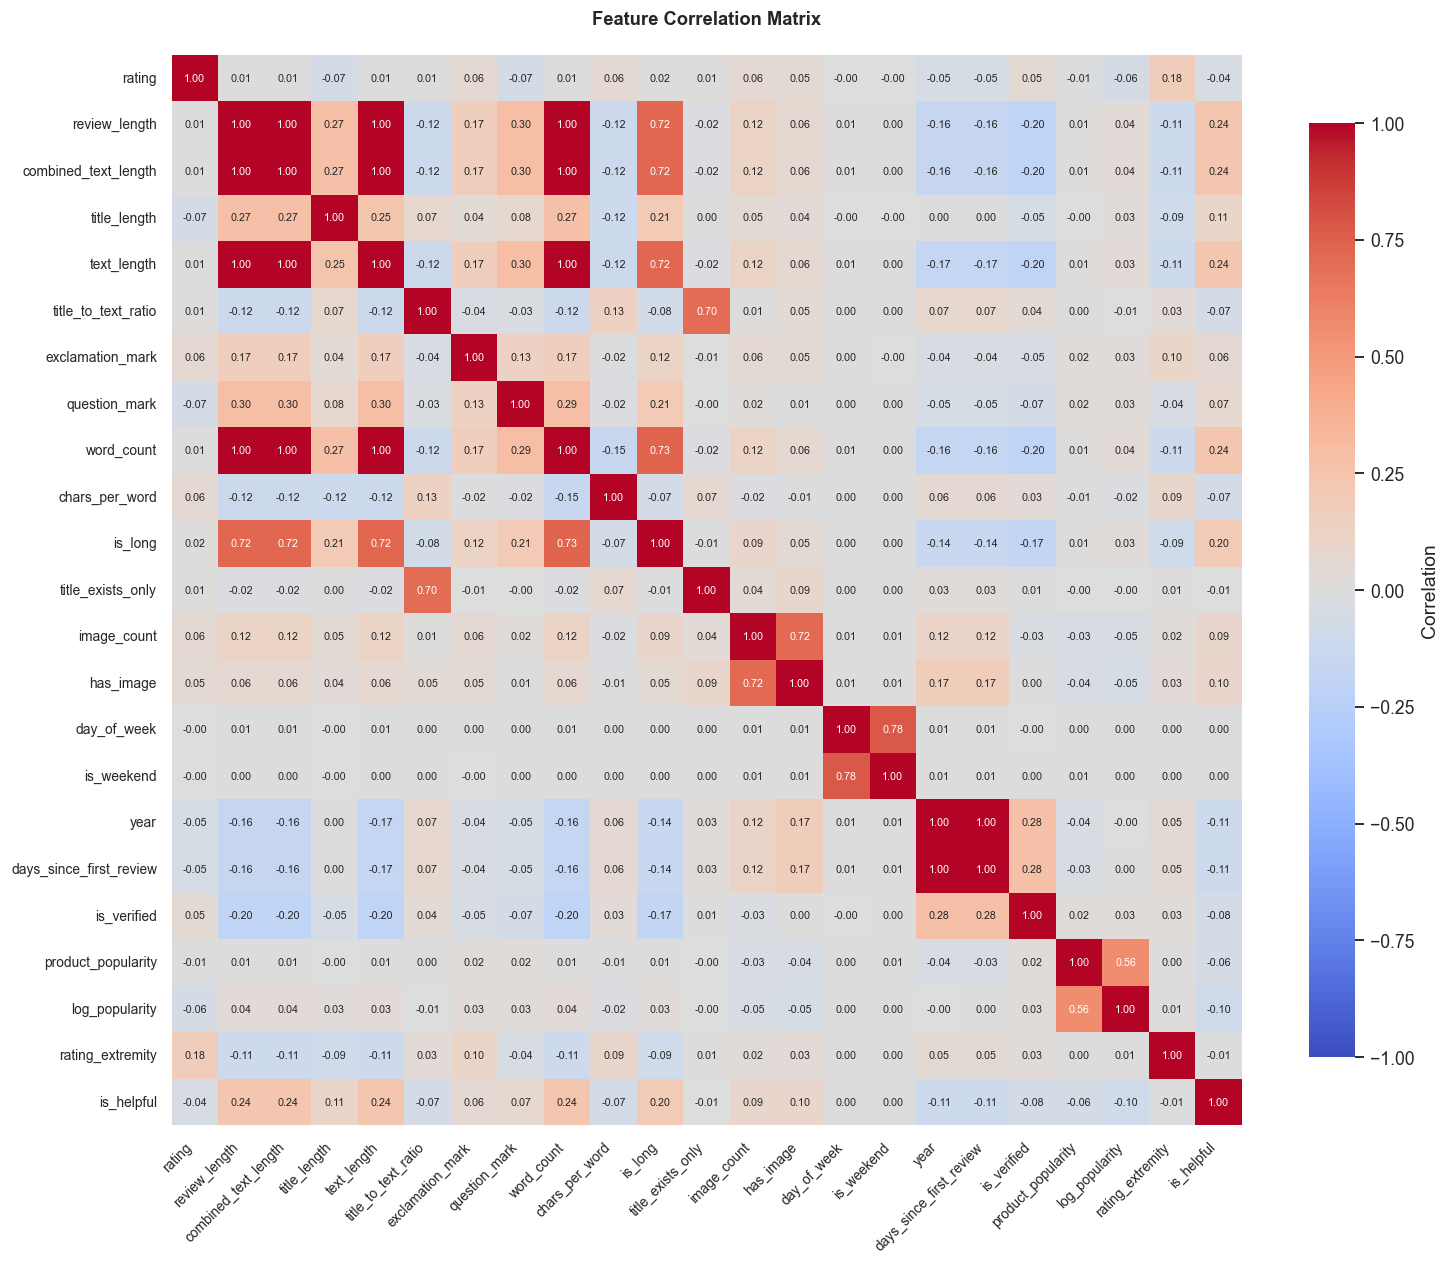


Key Correlations with Helpful Votes:
  word_count               :  0.2399
  review_length            :  0.2391
  combined_text_length     :  0.2391
  text_length              :  0.2379
  is_long                  :  0.1968
  title_length             :  0.1050
  has_image                :  0.1009
  image_count              :  0.0900
  question_mark            :  0.0723
  exclamation_mark         :  0.0615
  day_of_week              :  0.0042
  is_weekend               :  0.0016
  title_exists_only        : -0.0060
  rating_extremity         : -0.0090
  rating                   : -0.0436
  product_popularity       : -0.0580
  title_to_text_ratio      : -0.0661
  chars_per_word           : -0.0733
  is_verified              : -0.0772
  log_popularity           : -0.0954
  days_since_first_review  : -0.1132
  year                     : -0.1139


Helpful Votes by Rating:
          Count  Mean  Median
rating                       
1       1726551  0.52     1.0
2        581945  0.47     0.0
3

In [41]:
# CORRELATION ANALYSIS
print("CORRELATION ANALYSIS")
print("=" * 70)

# Numeric correlation matrix
corr_matrix = df[NUMERIC_COLS].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 7}, 
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

# Key insights
print("\nKey Correlations with Helpful Votes:")
helpful_corr = corr_matrix['is_helpful'].sort_values(ascending=False)
for col, val in helpful_corr.items():
    if col != 'is_helpful':
        print(f"  {col:25s}: {val:7.4f}")

# Helpful votes by rating
print(f"\n\nHelpful Votes by Rating:")
helpful_by_rating = df.groupby('rating')['is_helpful'].agg(['count', 'mean', 'median'])
helpful_by_rating.columns = ['Count', 'Mean', 'Median']
print(helpful_by_rating.round(2))

# Helpful votes by verified purchase
print(f"\n\nHelpful Votes by Verified Purchase:")
helpful_verified = df.groupby('is_verified')['is_helpful'].agg(['count', 'mean', 'median'])
helpful_verified.index = ['Not Verified', 'Verified']
helpful_verified.columns = ['Count', 'Mean', 'Median']
print(helpful_verified.round(2))

In [42]:
# Subset + drop missing target
sub = df[NUMERIC_COLS].copy()
sub = sub.dropna(subset=['is_helpful'])

print("Number of records dropped due to missing target:", df.shape[0] - sub.shape[0])

Number of records dropped due to missing target: 0


In [43]:
sub_sample = sub.sample(
    n=min(500_000, len(sub)),
    random_state=42
)

print("Number of records used for MI and VIF calculations:", sub_sample.shape[0])

Number of records used for MI and VIF calculations: 500000


=== Statistical Evidence — All Numeric Features ===

                Feature  MI_Score  Spearman_r          VIF  Significant  High_VIF
   combined_text_length    0.0504      0.3045 1.016041e+12         True      True
            text_length    0.0503      0.3050 1.528103e+09         True      True
          review_length    0.0494      0.3045 1.011136e+12         True      True
            is_verified    0.0490     -0.0768 1.100000e+00         True     False
             word_count    0.0481      0.3021 2.936000e+02         True      True
    title_to_text_ratio    0.0402     -0.2467 2.100000e+00         True     False
       rating_extremity    0.0330     -0.0103 1.100000e+00         True     False
         chars_per_word    0.0320     -0.0508 1.300000e+00         True     False
                 rating    0.0222     -0.0446 1.100000e+00         True     False
                is_long    0.0215      0.1966 2.200000e+00         True     False
                   year    0.0150     -0.0902

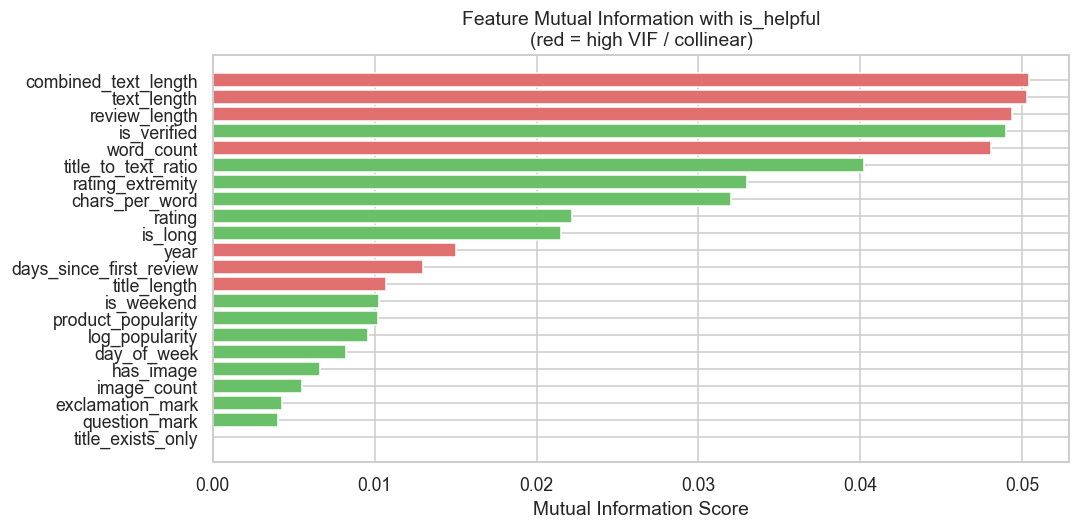

In [44]:
# Mutual Information (classification) — non-parametric, captures non-linear relationships
mi_scores = mutual_info_classif(
    sub_sample[NUMERIC_COLS.drop('is_helpful')],
    sub_sample['is_helpful'],
    random_state=42
)

# ── Spearman Correlation ──
sp_results = []
for feat in NUMERIC_COLS.drop('is_helpful'):
    r, p = stats.spearmanr(sub_sample[feat], sub_sample['is_helpful'])
    sp_results.append((feat, r, p))

# ── VIF (robust) ──
vif_sub = sub_sample[NUMERIC_COLS.drop('is_helpful')].copy()

# Drop zero-variance AFTER cleaning
vif_sub = vif_sub.loc[:, vif_sub.std() > 0]

# Final safety: ensure pure float matrix
vif_sub = vif_sub.astype(float)

vif_vals = [
    variance_inflation_factor(vif_sub.values, i)
    for i in range(vif_sub.shape[1])
]

vif_dict = dict(zip(vif_sub.columns, vif_vals))

# ── Assemble Evidence Table ──
evidence = pd.DataFrame({
    'Feature': NUMERIC_COLS.drop('is_helpful'),
    'MI_Score': mi_scores.round(4),
    'Spearman_r': [r for _, r, _ in sp_results],
    'Spearman_p': [p for _, _, p in sp_results],
    'VIF': [vif_dict.get(f, np.nan) for f in NUMERIC_COLS.drop('is_helpful')],
}).sort_values('MI_Score', ascending=False)

# Formatting
evidence['Spearman_r']  = evidence['Spearman_r'].round(4)
evidence['VIF']         = evidence['VIF'].round(1)
evidence['Significant'] = evidence['Spearman_p'] < 0.01
evidence['High_VIF']    = evidence['VIF'] > 10

print("=== Statistical Evidence — All Numeric Features ===\n")
print(
    evidence[['Feature', 'MI_Score', 'Spearman_r', 'VIF',
              'Significant', 'High_VIF']]
    .to_string(index=False)
)

# ── Plot MI Scores ──
fig, ax = plt.subplots(figsize=(10, 5))

sorted_ev = evidence.sort_values('MI_Score')

colors = [
    '#e07070' if v > 10 else '#6abf69'
    for v in sorted_ev['VIF']
]

ax.barh(
    sorted_ev['Feature'],
    sorted_ev['MI_Score'],
    color=colors,
    edgecolor='white'
)

ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Mutual Information with is_helpful\n(red = high VIF / collinear)')

plt.tight_layout()
plt.show()

## 9. Final Features

In [48]:
FINAL_FEATURES = [
    "rating",
    "review_length", 
    "chars_per_word", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "log_popularity",
    "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
    "images",
    "combined_text",
    "is_helpful", # target variable
]

for feat in FINAL_FEATURES:
    if feat not in df.columns:
        print(f"Warning: {feat} not found in DataFrame — skipping.")
    else:
        print(f"✓ Retaining feature: {feat}")

df_final = df[FINAL_FEATURES].copy()

✓ Retaining feature: rating
✓ Retaining feature: review_length
✓ Retaining feature: chars_per_word
✓ Retaining feature: image_bucket
✓ Retaining feature: days_since_first_review
✓ Retaining feature: is_verified
✓ Retaining feature: log_popularity
✓ Retaining feature: rating_extremity
✓ Retaining feature: question_mark
✓ Retaining feature: exclamation_mark
✓ Retaining feature: title_length
✓ Retaining feature: title_to_text_ratio
✓ Retaining feature: images
✓ Retaining feature: combined_text
✓ Retaining feature: is_helpful


## Final Summary

In [49]:
print("="*80)
print("FEATURE ENGINEERING COMPLETE")
print("="*80)
print(f"\nFinal Dataset Shape: {df_final.shape[0]:,} rows x {df_final.shape[1]:,} columns")
print(f"\nAll Features ({len(df_final.columns)}):")
for i, col in enumerate(df_final.columns, 1):
    print(f"  {i:2d}. {col}")

    
print(f"\nTarget Variable (is_helpful) Distribution:")
print(f"  Not Helpful (0): {(df_final['is_helpful']==0).sum():,} ({(df_final['is_helpful']==0).sum()/len(df_final)*100:.1f}%)")
print(f"  Helpful (1):     {(df_final['is_helpful']==1).sum():,} ({(df_final['is_helpful']==1).sum()/len(df_final)*100:.1f}%)")
print(f"\n✓ Feature Engineering Pipeline Completed Successfully!")

FEATURE ENGINEERING COMPLETE

Final Dataset Shape: 8,467,573 rows x 15 columns

All Features (15):
   1. rating
   2. review_length
   3. chars_per_word
   4. image_bucket
   5. days_since_first_review
   6. is_verified
   7. log_popularity
   8. rating_extremity
   9. question_mark
  10. exclamation_mark
  11. title_length
  12. title_to_text_ratio
  13. images
  14. combined_text
  15. is_helpful

Target Variable (is_helpful) Distribution:
  Not Helpful (0): 4,447,976 (52.5%)
  Helpful (1):     4,019,597 (47.5%)

✓ Feature Engineering Pipeline Completed Successfully!


## Export Featured Dataset

In [50]:
# Create output directory if it doesn't exist
os.makedirs(os.path.dirname(FEATURED_PARQUET), exist_ok=True)

# Export the featured dataset
df_final.to_parquet(FEATURED_PARQUET, index=False, engine="pyarrow")

print(f"✓ Featured dataset exported successfully!")
print(f"  File: {FEATURED_PARQUET}")
print(f"  Size: {df_final.shape[0]:,} rows x {df_final.shape[1]:,} columns")
print(f"  File size: {os.path.getsize(FEATURED_PARQUET) / (1024**2):.2f} MB")

✓ Featured dataset exported successfully!
  File: ../data/sourced/featured_reviews.parquet
  Size: 8,467,573 rows x 15 columns
  File size: 2774.84 MB


## Complete Feature Inventory -- All the features that are introduced

### Target Variable
| Feature | Description | Data Type |
|---------|-------------|----------|
| `is_helpful` | Binary target (1 if helpful_votes >= median threshold, else 0) | int8 |

### Text-Based Features
| Feature | Description | Data Type |
|---------|-------------|----------|
| `combined_text` | Title + ' [SEP] ' + Text for NLP models | string |
| `review_length` | Total character length of combined review text | int32 |
| `title_length` | Character length of review title | int16 |
| `text_length` | Character length of review text body | int32 |
| `title_to_text_ratio` | Ratio of title length to text length (zero-division safe) | float32 |
| `exclamation_mark` | Count of exclamation marks (!) in combined text | int16 |
| `question_mark` | Count of question marks (?) in combined text | int16 |
| `word_count` | Number of words in review_text | int32 |
| `chars_per_word` | Average characters per word (combined_text_length / word_count) | float32 |
| `is_long` | Binary: 1 if word_count > 200, else 0 | int8 |

### Image & Media Features
| Feature | Description | Data Type |
|---------|-------------|----------|
| `image_count` | Number of images attached to the review | int16 |
| `has_image` | Binary indicator (1 if review contains images, 0 otherwise) | int8 |
| `image_bucket` | Categorical: '0 images', '1 image', '2 images', or '3+ images' | category |

### Temporal Features
| Feature | Description | Data Type |
|---------|-------------|----------|
| `day_of_week` | Day of week posted (0=Monday, 6=Sunday) | int8 |
| `is_weekend` | Binary indicator (1 if posted on weekend, 0 otherwise) | int8 |
| `days_since_first_review` | Days elapsed since earliest review in dataset | int32 |
| `year` | Year the review was posted | int64 |

### Rating & Sentiment Features
| Feature | Description | Data Type |
|---------|-------------|----------|
| `sentiment` | Categorical: 'very_negative', 'negative', 'neutral', 'positive', 'very_positive' | object |
| `rating_extremity` | Distance from neutral rating: abs(rating - 3) | int64 |

### Purchase & Product Features
| Feature | Description | Data Type |
|---------|-------------|----------|
| `rating` | Review rating (1-5 stars) | int8 |
| `is_verified` | Binary verified purchase indicator (1=verified, 0=not verified) | int8 |
| `helpful_vote` | Number of helpful upvotes received | int32 |
| `parent_asin` | Parent product identifier (product family) | category |
| `product_popularity` | Total number of reviews for the product | int32 |

### Preserved Metadata
| Feature | Description | Data Type |
|---------|-------------|----------|
| `images` | List of image URLs/objects attached to review | list |
| `timestamp` | Review posting timestamp | datetime64 |